<a href="https://colab.research.google.com/github/gitronjun/SymSUTNet/blob/main/01_BreakHis40_BS16_150Epoch_Sym2Pool%2BPreSym2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.6 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, BatchNormalization, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pywt

In [ ]:
# Constants
NUM_CLASSES = 8
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 150
LEARNING_RATE = 0.0001

In [ ]:
def apply_symlet_preprocessing(image):
    # Convert to float32 if not already
    image = tf.cast(image, tf.float32)

    # Normalize the image
    image = image / 255.0

    # Convert to numpy for wavelet transform
    image_np = image.numpy()

    # Get batch size from input shape
    batch_size = image_np.shape[0]

    # Initialize output array
    processed_image = np.zeros((batch_size, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS))

    # Process each image in the batch
    for b in range(batch_size):
        # Process each channel
        for c in range(IMAGE_CHANNELS):
            # Get current channel data
            channel_data = image_np[b, :, :, c]

            # Perform wavelet decomposition
            coeffs = pywt.dwt2(channel_data, 'sym2', mode='symmetric')
            cA, (cH, cV, cD) = coeffs

            # Reconstruct
            reconstructed = pywt.idwt2((cA, (cH, cV, cD)), 'sym2', mode='symmetric')

            # Ensure correct size
            reconstructed = reconstructed[:IMAGE_HEIGHT, :IMAGE_WIDTH]

            # Store the result
            processed_image[b, :, :, c] = reconstructed

    # Ensure values are in valid range [0, 1]
    processed_image = np.clip(processed_image, 0, 1)

    # Convert back to tensor
    result = tf.convert_to_tensor(processed_image, dtype=tf.float32)

    return result

def preprocess_dataset(image, label):
    processed_image = tf.py_function(
        func=apply_symlet_preprocessing,
        inp=[image],
        Tout=tf.float32
    )
    processed_image.set_shape(image.shape)
    return processed_image, label

class SymletPooling2D(Layer):
    def __init__(self, pool_size=(2, 2), **kwargs):
        super(SymletPooling2D, self).__init__(**kwargs)
        self.pool_size = pool_size

        # Symlet-inspired coefficients (sym2)
        h0 = tf.constant([-0.1294, 0.2241, 0.8365, 0.4830], dtype=tf.float32)

        # Reshape coefficients for 2D convolution
        self.h0 = tf.reshape(tf.tensordot(h0, h0, axes=0), [4, 4, 1, 1])

    def call(self, inputs):
        channels = tf.shape(inputs)[-1]
        h0 = tf.tile(self.h0, [1, 1, channels, 1])
        x = tf.nn.depthwise_conv2d(inputs, h0, strides=[1, 2, 2, 1], padding='SAME')
        return x

    def compute_output_shape(self, input_shape):
        return (input_shape[0],
                input_shape[1] // 2,
                input_shape[2] // 2,
                input_shape[3])

    def get_config(self):
        config = super().get_config()
        config.update({"pool_size": self.pool_size})
        return config

# Data loading
train_dir = '/content/drive/MyDrive/notebooks_boom/21_BreaKHis40XOnly/train'
test_dir = '/content/drive/MyDrive/notebooks_boom/21_BreaKHis40XOnly/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    validation_split=0.25,
    subset="training",
    seed=123,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    validation_split=0.25,
    subset="validation",
    seed=123,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

# Configure datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
preprocessed_train_ds = (train_ds
    .map(preprocess_dataset, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE))

preprocessed_val_ds = (val_ds
    .map(preprocess_dataset, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE))

preprocessed_test_ds = (test_ds
    .map(preprocess_dataset, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE))

def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS),
               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        SymletPooling2D(),
        Dropout(0.3),

        Conv2D(64, (3, 3), activation='relu', padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        SymletPooling2D(),
        Dropout(0.3),

        Conv2D(128, (3, 3), activation='relu', padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        SymletPooling2D(),
        Dropout(0.4),

        Conv2D(256, (3, 3), activation='relu', padding='same',
               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        BatchNormalization(),
        SymletPooling2D(),
        Dropout(0.5),

        Flatten(),
        Dense(512, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Build and train model
model = build_model()
model.summary()

Found 5067 files belonging to 8 classes.
Using 3801 files for training.
Found 5067 files belonging to 8 classes.
Using 1266 files for validation.
Found 399 files belonging to 8 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ symlet_pooling2d (SymletPooling2D)   │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ symlet_pooling2d_1 (SymletPooling2D) │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ symlet_pooling2d_2 (SymletPooling2D) │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ symlet_pooling2d_3 (SymletPooling2D) │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,085,064 (99.51 MB)

 Trainable params: 26,084,104 (99.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    preprocessed_train_ds,
    validation_data=preprocessed_val_ds,
    epochs=EPOCHS,
    callbacks=[reduce_lr],
    verbose=1
)

Epoch 1/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 133s 153ms/step - accuracy: 0.3105 - loss: 17.5414 - val_accuracy: 0.1335 - val_loss: 24.9819 - learning_rate: 1.0000e-04
Epoch 2/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4749 - loss: 14.4132 - val_accuracy: 0.2180 - val_loss: 19.8332 - learning_rate: 1.0000e-04
Epoch 3/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5465 - loss: 13.5381 - val_accuracy: 0.4415 - val_loss: 14.0525 - learning_rate: 1.0000e-04
Epoch 4/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5927 - loss: 12.7609 - val_accuracy: 0.5758 - val_loss: 12.5422 - learning_rate: 1.0000e-04
Epoch 5/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6657 - loss: 11.9694 - val_accuracy: 0.6019 - val_loss: 12.1013 - learning_rate: 1.0000e-04
Epoch 6/150
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7037 - loss: 11.2278 - val_accuracy: 0.5537 - val_loss: 11.5592 - learning_rate: 1.0000e-04
Epoch 7/150
238/238 ━━━━━━━━━━━━━━━━━

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(preprocessed_test_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - accuracy: 0.7844 - loss: 1.2205
Test Loss: 0.9778769612312317, Test Accuracy: 0.8370927572250366


In [ ]:
# Save model
save_path = '/content/drive/MyDrive/notebooks_boom/results/811.4_BreakHis40xOnly_Augment_4Block_5Epoch_Sym2(4 coefficients)_Sym2Pool+PreprocessSym2'
model.save(f'{save_path}/optimized_model_symlet.h5')

In [ ]:
# Confusion Matrix and Classification Report
y_true = np.concatenate([np.argmax(y, axis=1) for _, y in preprocessed_test_ds])
y_pred_probs = model.predict(preprocessed_test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)
class_names = test_ds.class_names
print("Confusion Matrix:\n", conf_matrix)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Confusion Matrix:
 [[ 23   0   0   0   0   1   0   0]
 [  0 146   1  11   3   6   0   0]
 [  0   0  44   0   0   0   2   0]
 [  1   6   0  19   0   0   0   0]
 [  0   2   1   2  31   1   0   0]
 [  0   5   0   0   1  40   0   0]
 [  1   0   0   1   0   0  17   1]
 [  0   5   8   0   1   3   2  14]]


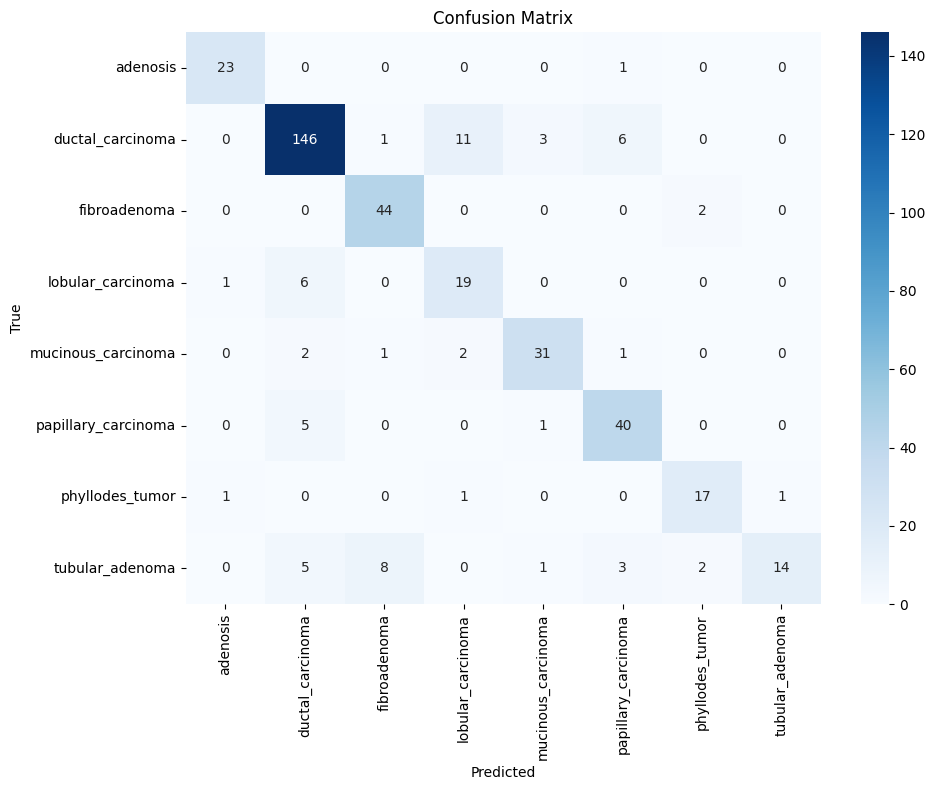

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
class_report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n", class_report)

Classification Report:
                      precision    recall  f1-score   support

           adenosis     0.9200    0.9583    0.9388        24
   ductal_carcinoma     0.8902    0.8743    0.8822       167
       fibroadenoma     0.8148    0.9565    0.8800        46
  lobular_carcinoma     0.5758    0.7308    0.6441        26
 mucinous_carcinoma     0.8611    0.8378    0.8493        37
papillary_carcinoma     0.7843    0.8696    0.8247        46
    phyllodes_tumor     0.8095    0.8500    0.8293        20
    tubular_adenoma     0.9333    0.4242    0.5833        33

           accuracy                         0.8371       399
          macro avg     0.8236    0.8127    0.8040       399
       weighted avg     0.8474    0.8371    0.8328       399



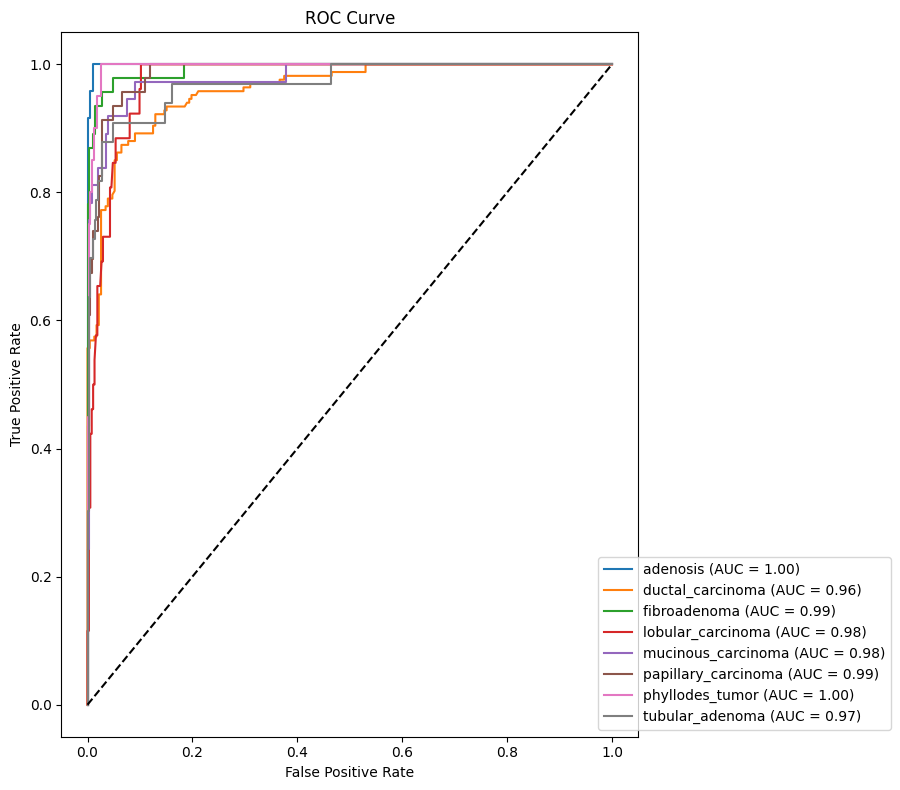

In [ ]:
# ROC Curve
plt.figure(figsize=(10, 8))
n_classes = len(class_names)
y_true_binarized = label_binarize(y_true, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right', bbox_to_anchor=(1.45, 0))
plt.tight_layout()
plt.show()

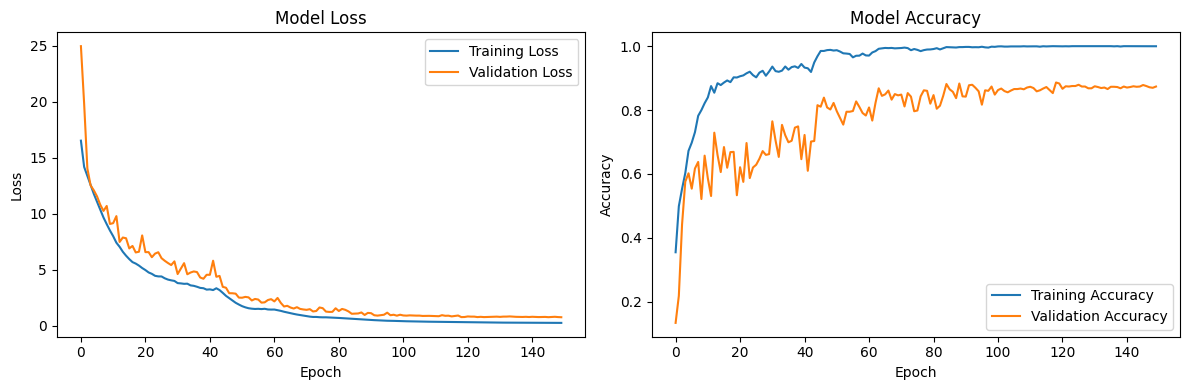

In [ ]:
# Plot training & validation loss and accuracy values
history_dict = history.history

plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'{save_path}/Model_Loss_Symlet.png')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'{save_path}/Model_Accuracy_Symlet.png')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluation function
def evaluate_model(model, test_ds):
    y_true = []
    y_pred_probs = []

    for images, labels in test_ds:
        batch_pred = model.predict(images)
        y_true.extend(np.argmax(labels, axis=1))
        y_pred_probs.extend(batch_pred)

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)

    conf_matrix = confusion_matrix(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )

    print("\nEvaluation Results:")
    print("Confusion Matrix:\n", conf_matrix)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return conf_matrix, precision, recall, f1

In [ ]:
# Save the model
model.save('symlet_breast_cancer_model.h5')